In [1]:
import json
from molrl.dataloader import create_dataloader
from molrl.nnx_modules import SmilesEncoder, SmilesDecoder, PredictionHead
from molrl.models import EncoderPredictor, JointMolecularModel, SmilesAutoencoder
from molrl.training import joint_model_train_step, joint_model_val_step
from molrl.eval import smiles_validity, levenshtein_distance
from molrl.tokenizer import encoding_to_smiles
from flax import nnx
from jax import numpy as jnp
import numpy as np
import optax
import orbax.checkpoint as ocp
from pathlib import Path
import random
import pandas as pd

In [2]:
# --- Architecture configs (fixed from pretraining) ---
oracle_ckpt_dir = (Path.cwd() / "checkpoints/pretrained_oracle").resolve()
ae_ckpt_dir = (Path.cwd() / "../step_3_pretrain_autoencoder/checkpoints/pretrained_autoencoder").resolve()

with open(oracle_ckpt_dir.parent / "best_oracle_config.json") as f:
    oracle_config = json.load(f)

arch = {
    "vocab_size": 36,
    "max_seq_len": 102,
    "latent_dim": 128,
    "encoder_emb_dim": oracle_config["encoder_emb_dim"],
    "encoder_conv_channels": tuple(oracle_config["encoder_conv_channels"]),
    "encoder_kernel_sizes": tuple(oracle_config["encoder_kernel_sizes"]),
    "encoder_dropout_rate": oracle_config["encoder_dropout_rate"],
    "decoder_hidden_dim": 512,
    "decoder_emb_dim": 64,
    "prediction_head_hidden_dims": tuple(oracle_config["prediction_head_hidden_dim"] for _ in range(oracle_config["prediction_head_n_layers"])),
    "prediction_head_dropout_rate": oracle_config["prediction_head_dropout_rate"],
}


def build_pretrained_jmm() -> JointMolecularModel:
    """Build a JointMolecularModel and load pretrained weights from oracle + autoencoder checkpoints."""
    encoder = SmilesEncoder(
        vocab_size=arch["vocab_size"], latent_dim=arch["latent_dim"],
        emb_dim=arch["encoder_emb_dim"], conv_channels=arch["encoder_conv_channels"],
        kernel_sizes=arch["encoder_kernel_sizes"], dropout_rate=arch["encoder_dropout_rate"])

    decoder = SmilesDecoder(
        vocab_size=arch["vocab_size"], max_seq_len=arch["max_seq_len"],
        latent_dim=arch["latent_dim"], hidden_dim=arch["decoder_hidden_dim"],
        emb_dim=arch["decoder_emb_dim"])

    prediction_head = PredictionHead(
        latent_dim=arch["latent_dim"], hidden_dims=arch["prediction_head_hidden_dims"],
        dropout_rate=arch["prediction_head_dropout_rate"])

    jmm = JointMolecularModel(encoder, decoder, prediction_head)

    # restore oracle weights (encoder + prediction_head)
    checkpointer = ocp.PyTreeCheckpointer()
    oracle_template = EncoderPredictor(
        SmilesEncoder(vocab_size=arch["vocab_size"], latent_dim=arch["latent_dim"],
                      emb_dim=arch["encoder_emb_dim"], conv_channels=arch["encoder_conv_channels"],
                      kernel_sizes=arch["encoder_kernel_sizes"], dropout_rate=arch["encoder_dropout_rate"]),
        PredictionHead(latent_dim=arch["latent_dim"], hidden_dims=arch["prediction_head_hidden_dims"],
                       dropout_rate=arch["prediction_head_dropout_rate"]))
    oracle_state = checkpointer.restore(str(oracle_ckpt_dir), item=nnx.state(oracle_template))
    nnx.update(oracle_template, oracle_state)

    # restore AE weights (decoder)
    ae_template = SmilesAutoencoder(
        SmilesEncoder(vocab_size=arch["vocab_size"], latent_dim=arch["latent_dim"],
                      emb_dim=arch["encoder_emb_dim"], conv_channels=arch["encoder_conv_channels"],
                      kernel_sizes=arch["encoder_kernel_sizes"], dropout_rate=arch["encoder_dropout_rate"]),
        SmilesDecoder(vocab_size=arch["vocab_size"], max_seq_len=arch["max_seq_len"],
                      latent_dim=arch["latent_dim"], hidden_dim=arch["decoder_hidden_dim"],
                      emb_dim=arch["decoder_emb_dim"]))
    ae_state = checkpointer.restore(str(ae_ckpt_dir), item=nnx.state(ae_template))
    nnx.update(ae_template, ae_state)

    # transfer into JMM
    nnx.update(jmm.encoder, nnx.state(oracle_template.encoder))
    nnx.update(jmm.prediction_head, nnx.state(oracle_template.prediction_head))
    nnx.update(jmm.decoder, nnx.state(ae_template.decoder))

    return jmm


# quick test
jmm = build_pretrained_jmm()
print(f"JMM ready. Encoder + PredictionHead from oracle, Decoder from AE.")

config = {
    "batch_size": 256,
    "n_epochs": 200,
    "early_stop_patience_evals": 10,
    "lambda_": 1.0,
    "lr": 1e-5,
    "model_save_path": "checkpoints/finetuned_jmm",
}

train_loader = create_dataloader("../step_1_data_preparation/chembl224_ki_train_aug.h5",
                                 batch_size=config["batch_size"], shuffle=True, to_device=True)
val_loader = create_dataloader("../step_1_data_preparation/chembl224_ki_val_aug.h5",
                               batch_size=config["batch_size"], shuffle=True, to_device=True)

ckpt_dir = (Path.cwd() / config["model_save_path"]).resolve()
ckpt_dir.parent.mkdir(parents=True, exist_ok=True)
checkpointer = ocp.PyTreeCheckpointer()

JMM ready. Encoder + PredictionHead from oracle, Decoder from AE.


/Users/derekvantilborg/Dropbox/coding/OOD-proof-mol-RL/.venv/lib/python3.13/site-packages/orbax/checkpoint/_src/serialization/jax_array_handlers.py:712: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


In [ ]:
model = build_pretrained_jmm()
optimizer = nnx.Optimizer(model, optax.adamw(config["lr"]), wrt=nnx.Param)

best_val_loss = float("inf")
no_improve = 0

for epoch in range(config["n_epochs"]):
    train_total, train_recon, train_pred = 0.0, 0.0, 0.0
    for train_batch in train_loader:
        total, recon, pred = joint_model_train_step(model, optimizer, train_batch, lambda_=config["lambda_"])
        train_total += float(total)
        train_recon += float(recon)
        train_pred += float(pred)

    val_total, val_recon, val_pred = 0.0, 0.0, 0.0
    smiles_pairs = []
    reconstructed_smiles = []
    for val_batch in val_loader:
        total, recon, pred = joint_model_val_step(model, val_batch, lambda_=config["lambda_"])
        val_total += float(total)
        val_recon += float(recon)
        val_pred += float(pred)

        # reconstruction metrics (on val batches)
        input_ids = jnp.asarray(val_batch[0], dtype=jnp.int32)
        logits, _, _ = model(input_ids, input_ids, is_training=False)
        pred_tokens = jnp.argmax(logits, axis=-1)
        for j in range(pred_tokens.shape[0]):
            inp_smi = encoding_to_smiles(input_ids[j].tolist())
            rec_smi = encoding_to_smiles(pred_tokens[j].tolist())
            if rec_smi is not None:
                reconstructed_smiles.append(rec_smi)
            if inp_smi is not None and rec_smi is not None:
                smiles_pairs.append((inp_smi, rec_smi))

    n = len(train_loader)
    train_total /= n; train_recon /= n; train_pred /= n
    m = len(val_loader)
    val_total /= m; val_recon /= m; val_pred /= m

    if epoch % 5 == 0:
        validity = smiles_validity(reconstructed_smiles) if reconstructed_smiles else 0.0
        avg_edit = np.mean([levenshtein_distance(a, b) for a, b in smiles_pairs]) if smiles_pairs else float("nan")

        print(f"Ep {epoch}: train [total={train_total:.4f} recon={train_recon:.4f} pred={train_pred:.4f}]"
              f"  val [total={val_total:.4f} recon={val_recon:.4f} pred={val_pred:.4f}]"
              f"  validity={validity:.3f} edit_dist={avg_edit:.1f}")
        if smiles_pairs:
            inp, rec = random.choice(smiles_pairs)
            print(f"  IN:  {inp}")
            print(f"  OUT: {rec}")

    if val_total < best_val_loss:
        best_val_loss = val_total
        no_improve = 0
        checkpointer.save(str(ckpt_dir), nnx.state(model), force=True)
        with open(ckpt_dir.parent / "best_jmm_config.json", "w") as f:
            json.dump(config, f, indent=2)
    else:
        no_improve += 1
        if no_improve >= config["early_stop_patience_evals"]:
            print(f"Early stopping at epoch {epoch} (best val: {best_val_loss:.4f})")
            break

print(f"\nBest val loss: {best_val_loss:.4f}")
print(f"Checkpoint at: {ckpt_dir}")

Ep 0: train [total=5.7669 recon=5.4947 pred=0.2722]  val [total=4.2164 recon=3.4615 pred=0.7549]  validity=0.006 edit_dist=37.2
  IN:  C(CCOn1c(O)c2c(c1O)C1C(CC2(C=C1C)OC(=O)C)C)N1CCN(c2cc(Cl)ccc2)CC1
  OUT: c(OO1C1c2cCcccccc)CC(cCCCC)CCCC))CC)CO)C)s)sC
Ep 5: train [total=1.6336 recon=1.4079 pred=0.2257]  val [total=1.8535 recon=1.2496 pred=0.6039]  validity=0.018 edit_dist=27.3
  IN:  c1cccc2C3(CN)CCC(c21)c1ccccc13
  OUT: c1c(cccc(NCC(((CCC3c)c1c(ccc1C
Ep 10: train [total=1.3201 recon=1.1228 pred=0.1973]  val [total=1.6216 recon=1.0482 pred=0.5734]  validity=0.001 edit_dist=23.8
  IN:  c1(-c2ccc(cc2)F)[nH]nc2CCNCCc12
  OUT: c12Cc2cc((cc2)C)onH]nncCNC(CN22
Ep 15: train [total=1.2015 recon=1.0195 pred=0.1820]  val [total=1.5342 recon=0.9733 pred=0.5609]  validity=0.001 edit_dist=22.3
  IN:  o1nc(CCCN2CC(CC2)NS(c2cc(ccc2)C)(=O)=O)c2ccccc12
  OUT: c1cc(cCCN2CCNCC2)C2(=2cccccc2)C)(=O)=O)ccccccc22
Ep 20: train [total=1.1447 recon=0.9625 pred=0.1822]  val [total=1.5245 recon=0.9385 pred=0.58

In [3]:
# init model architecture (same as training)
model = build_pretrained_jmm()

# load best model for evaluation
best_model_state = checkpointer.restore(str(ckpt_dir), item=nnx.state(model))
nnx.update(model, best_model_state)

In [4]:
# perform inference on the test set
from molrl.cheminformatics import calculate_ecfps, tanimoto_one_to_many
from jax import vmap
from molrl.training import joint_model_predict
from tqdm.asyncio import tqdm

max_tanimoto_to_set = vmap(tanimoto_one_to_many, (0, None))

test_loader = create_dataloader("../step_1_data_preparation/chembl224_ki_test_aug.h5",
                                batch_size=config["batch_size"], shuffle=False, to_device=True)
test_smiles = pd.read_csv("../step_1_data_preparation/chembl224_ki_test_aug.csv")["standardized_smiles"].tolist()
train_fps = jnp.array(calculate_ecfps(test_smiles, radius=2, nbits=1024)).astype('float16')

unfamiliarity = []
y_hat = []
y_true = []
error = []
tanimoto_to_train = []
input_smiles = []
reconstructed_smiles = []

for batch in tqdm(test_loader):
    x, y = batch
    pred, unf, z, smi_in, smi_out = joint_model_predict(model, batch, pad_token_id=0)

    fps = jnp.array(calculate_ecfps(smi_in, radius=2, nbits=1024)).astype('float16')
    sim = max_tanimoto_to_set(fps, train_fps).mean(axis=1)

    error.extend(np.abs(pred - y).tolist())
    unfamiliarity.extend(unf.tolist())
    y_hat.extend(pred.tolist())
    y_true.extend(y.tolist())
    input_smiles.extend(smi_in)
    reconstructed_smiles.extend(smi_out)
    tanimoto_to_train.extend(sim.tolist())

/Users/derekvantilborg/Dropbox/coding/OOD-proof-mol-RL/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 18/18 [00:30<00:00,  1.67s/it]


In [5]:
from scipy.stats import spearmanr
from sklearn.metrics import r2_score, root_mean_squared_error
from numpy.polynomial.polynomial import polyfit, polyval

# arrays
unf_arr = np.array(unfamiliarity)
err_arr = np.array(error)
tanimoto_dist = np.array([1 - t for t in tanimoto_to_train])

# overall metrics
r2 = r2_score(y_true, y_hat)
rmse = root_mean_squared_error(y_true, y_hat)

# spearman correlations
rho_ue, pval_ue = spearmanr(unf_arr, err_arr)
rho_ut, pval_ut = spearmanr(unf_arr, tanimoto_dist)
rho_et, pval_et = spearmanr(err_arr, tanimoto_dist)

# calibration bins
n_bins = 10
bin_edges = np.quantile(unf_arr, np.linspace(0, 1, n_bins + 1))
bin_indices = np.digitize(unf_arr, bin_edges[1:-1])
bin_mean_unf, bin_mean_err, bin_std_err, bin_counts = [], [], [], []
for b in range(n_bins):
    mask = bin_indices == b
    if mask.sum() == 0:
        continue
    bin_mean_unf.append(unf_arr[mask].mean())
    bin_mean_err.append(err_arr[mask].mean())
    bin_std_err.append(err_arr[mask].std())
    bin_counts.append(mask.sum())
bin_mean_unf = np.array(bin_mean_unf)
bin_mean_err = np.array(bin_mean_err)
bin_std_err = np.array(bin_std_err)
bin_counts = np.array(bin_counts)
coeffs = polyfit(bin_mean_unf, bin_mean_err, 1)
expected_err = polyval(bin_mean_unf, coeffs)
ece = np.average(np.abs(bin_mean_err - expected_err), weights=bin_counts)

# dataframes for plotnine
df_scatter = pd.DataFrame({
    "unfamiliarity": unf_arr, "error": err_arr, "tanimoto_dist": tanimoto_dist
})
df_cal = pd.DataFrame({
    "unfamiliarity": bin_mean_unf, "mean_error": bin_mean_err,
    "std_error": bin_std_err, "expected": expected_err
})

print(f"R² = {r2:.4f}, RMSE = {rmse:.4f}")
print(f"Spearman: unfamiliarity↔error ρ={rho_ue:.4f}, unfamiliarity↔tanimoto_dist ρ={rho_ut:.4f}, error↔tanimoto_dist ρ={rho_et:.4f}")
print(f"ECE = {ece:.4f}")

R² = 0.3347, RMSE = 0.9869
Spearman: unfamiliarity↔error ρ=0.2878, unfamiliarity↔tanimoto_dist ρ=0.6967, error↔tanimoto_dist ρ=0.3295
ECE = 0.0294


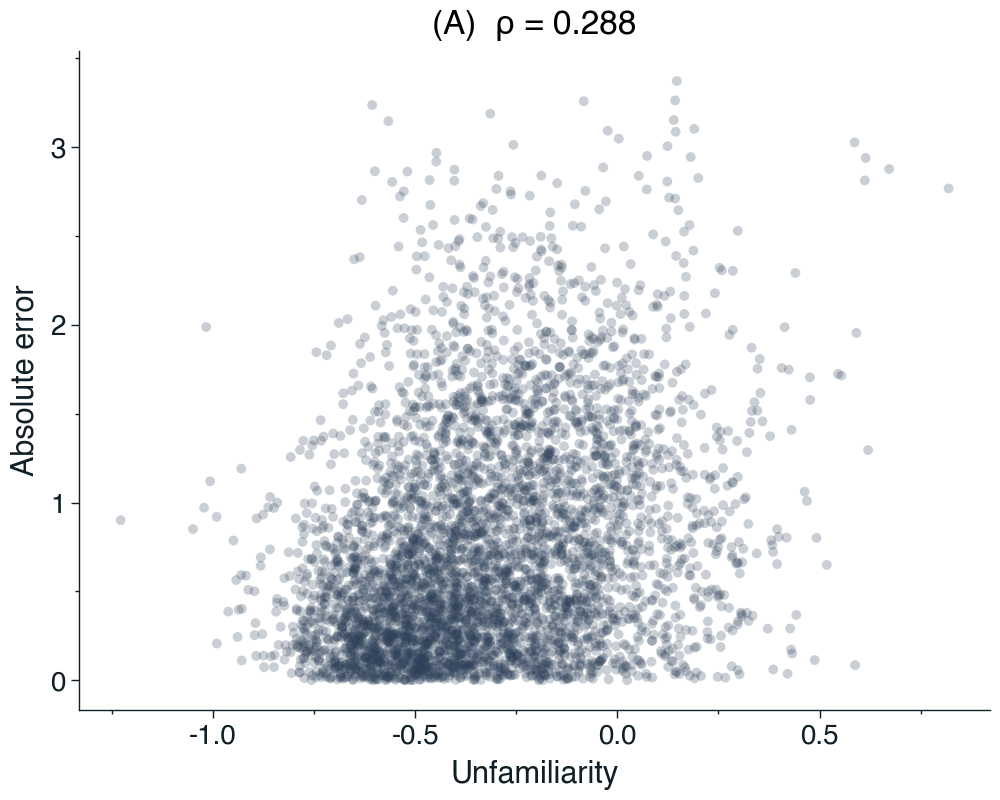

In [42]:
from plotnine import *

col_scatter = '#2d4059'
col_cal     = '#2d4059'
col_fit     = '#c44e52'

default_theme = theme(
    panel_border=element_blank(),
    panel_background=element_blank(),
    plot_title=element_text(ha="center", size=12, weight="bold"),
    axis_text_y=element_text(size=10, style="normal", color="#101e25"),
    axis_text_x=element_text(size=10, style="normal", color="#101e25"),
    axis_title_x=element_text(size=11, style="normal", color="#101e25"),
    axis_title_y=element_text(size=11, style="normal", color="#101e25"),
    axis_ticks=element_line(color="#101e25", size=0.5),
    axis_line_x=element_line(color="#101e25", size=0.5),
    axis_line_y=element_line(color="#101e25", size=0.5),
    legend_key=element_blank(),
    legend_position="right",
    legend_title=element_text(size=10),
    legend_background=element_blank(),
    legend_text=element_text(size=10),
    panel_grid_major=element_blank(),
    panel_grid_minor=element_blank(),
    figure_size=(5, 4),
)

# (A) Unfamiliarity vs Error
(ggplot(df_scatter, aes("unfamiliarity", "error"))
 + geom_point(alpha=0.25, size=2, color=col_scatter, stroke=0)
 + labs(title=f"(A)  ρ = {rho_ue:.3f}", x="Unfamiliarity", y="Absolute error")
 + default_theme)

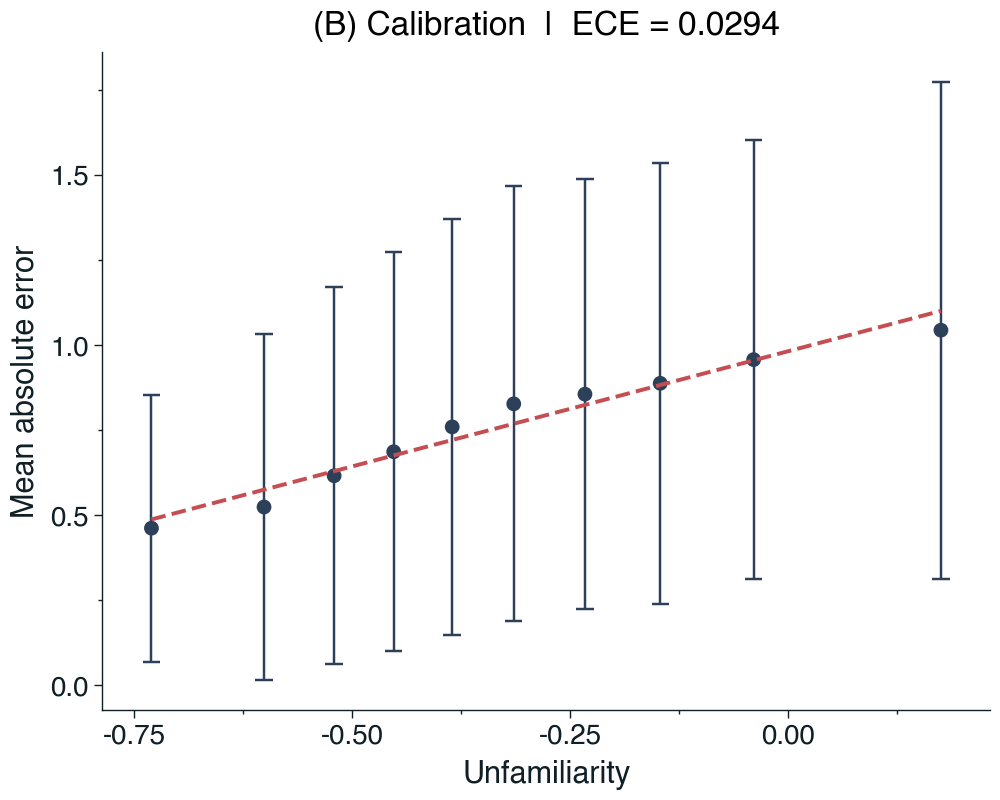

In [43]:
# (B) Calibration
(ggplot(df_cal, aes("unfamiliarity", "mean_error"))
 + geom_errorbar(aes(ymin="mean_error - std_error", ymax="mean_error + std_error"),
                 width=0.02, color=col_cal, size=0.5)
 + geom_point(size=2, color=col_cal)
 + geom_line(aes(y="expected"), color=col_fit, linetype="dashed", size=0.8)
 + labs(title=f"(B) Calibration  |  ECE = {ece:.4f}", x="Unfamiliarity", y="Mean absolute error")
 + default_theme)

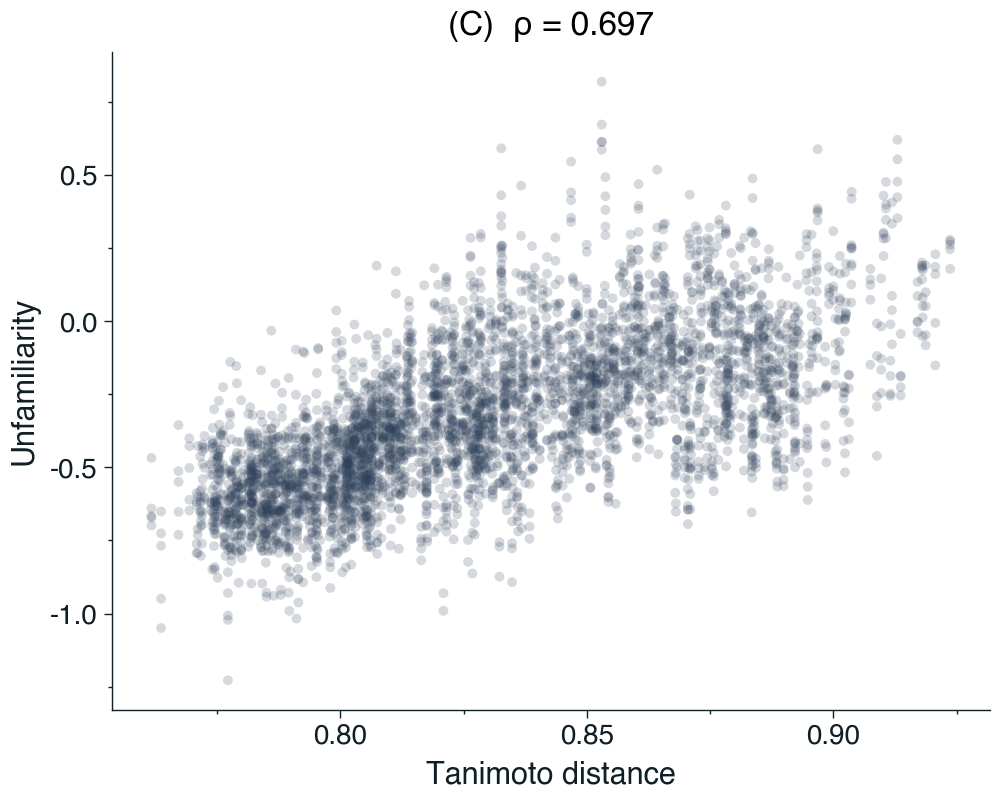

In [44]:
# (C) Tanimoto dist vs Unfamiliarity
(ggplot(df_scatter, aes("tanimoto_dist", "unfamiliarity"))
 + geom_point(alpha=0.2, size=2, color=col_scatter, stroke=0)
 + labs(title=f"(C)  ρ = {rho_ut:.3f}", x="Tanimoto distance", y="Unfamiliarity")
 + default_theme)

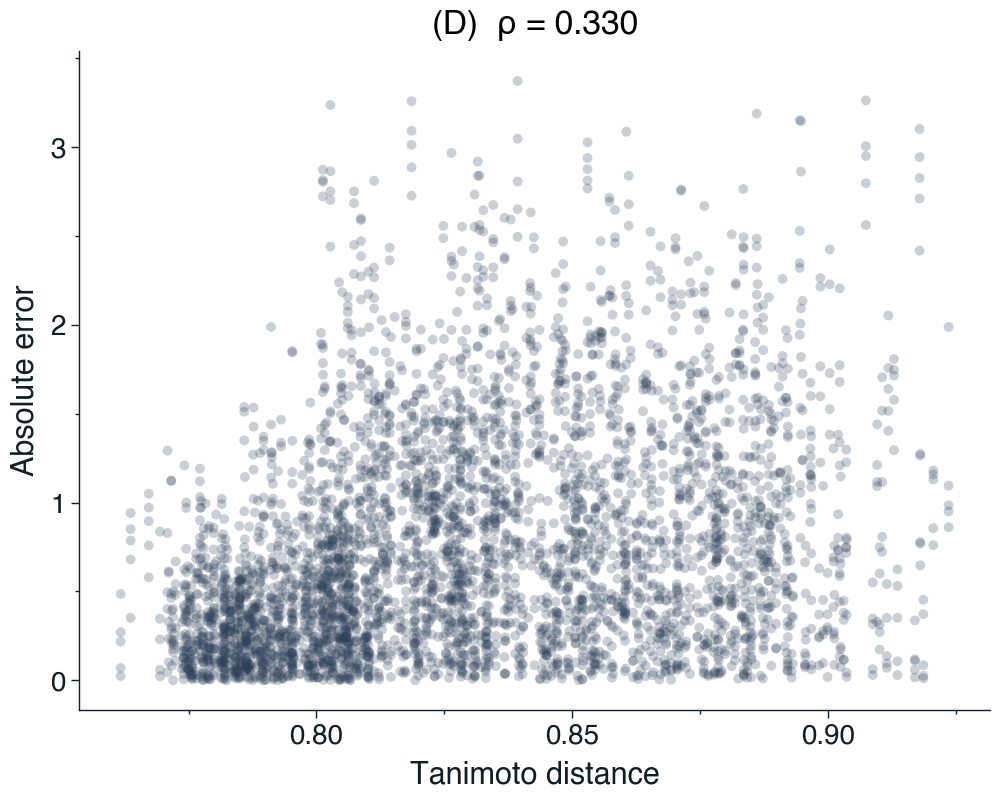

In [45]:
# (D) Tanimoto dist vs Error
(ggplot(df_scatter, aes("tanimoto_dist", "error"))
 + geom_point(alpha=0.25, size=2, color=col_scatter, stroke=0)
 + labs(title=f"(D)  ρ = {rho_et:.3f}", x="Tanimoto distance", y="Absolute error")
 + default_theme)

## Summary

### Oracle performance
The finetuned JMM achieves reasonable predictive accuracy on the held-out test set (scaffold split). The RMSE and R² are in line with what we'd expect for a pKi regression task — the model is usable as an oracle for RL.

### Unfamiliarity as an OOD signal
The key question is whether the unfamiliarity score (log reconstruction loss) can flag molecules where the oracle is unreliable. The results are encouraging:

- **Unfamiliarity tracks structural OOD-ness well** (ρ ≈ 0.70 with Tanimoto distance to training set). Molecules that are structurally distant from the training data receive high unfamiliarity scores. This is exactly what the autoencoder-based signal is designed to capture.
- **Unfamiliarity correlates weakly with prediction error** (ρ ≈ 0.29). Being far from the training distribution does *not* automatically mean the prediction is wrong — many structurally novel molecules happen to fall near the learned regression surface. But on average, higher unfamiliarity does mean higher error, and the calibration plot (ECE ≈ 0.03) confirms this trend is monotonic and well-behaved.
- **Tanimoto distance also correlates weakly with error** (ρ ≈ 0.33), so structural distance alone is a weak predictor of oracle failure. This is unsurprising — prediction error depends on the specific property landscape, not just molecular similarity.

### Implications for the RL loop
These results support using the unfamiliarity-weighted scoring function `score(x) = pKi(x) · w(unfamiliarity(x))` during RL:

1. **The oracle is good enough.** Predictive performance is solid within-distribution, so the RL agent has a meaningful signal to optimise.
2. **Unfamiliarity will dampen scores in uncharted territory.** Even though unfamiliarity doesn't perfectly predict *when* the oracle is wrong, it reliably detects *where* the oracle has never seen data. Dampening rewards in these regions is a conservative strategy that should prevent the agent from exploiting extrapolation artefacts.
3. **The weak ρ(unfamiliarity↔error) is actually fine.** We don't need unfamiliarity to predict error — we need it to prevent the agent from *systematically drifting* into regions where error could be arbitrarily bad. A monotonically increasing mean error with unfamiliarity (panel B) is sufficient for this purpose.
4. **The scaling parameter matters.** Given the moderate correlation, the unfamiliarity weighting temperature will need tuning: too aggressive and the agent is over-constrained; too mild and reward hacking can still occur.
